# Phase 2 | 04. Evaluation Metrics

RMSE measures prediction accuracy — how close our estimated ratings are to actual ratings.
But it says nothing about **recommendation quality**: are we surfacing items users actually care about?
Are we diversifying across the catalog, or just recommending the same 100 blockbusters to everyone?

This notebook implements four industry-standard metrics from scratch:

| Metric | What it measures |
|--------|------------------|
| RMSE | Prediction accuracy (baseline) |
| NDCG@10 | Ranking quality — are relevant items ranked higher? |
| Catalog Coverage | What % of items does the model ever recommend? |
| Long-tail Exposure Rate | How often does the model surface niche (non-popular) items? |

The last two connect directly back to the **popularity bias** finding from Phase 1.

## 1. Setup

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

sys.path.append('../')
from sklearn.model_selection import train_test_split
from src.mf_model import MatrixFactorization

In [12]:
# --- data (identical setup to notebook 03) ---
ratings = pd.read_parquet('../data/processed/ratings.parquet')

ratings_small = ratings.sample(frac=0.02, random_state=42)
train, test = train_test_split(ratings_small, test_size=0.2, random_state=42)

train_array = train[['userId', 'movieId', 'rating']].values
test_array  = test[['userId', 'movieId', 'rating']].values

print(f"train: {train_array.shape}, test: {test_array.shape}")

train: (400001, 3), test: (100001, 3)


In [13]:
# --- train model with best params from notebook 03 ---
model = MatrixFactorization(
    n_factors=20,
    lr=0.005,
    lambda_=0.05,
    n_epochs=100,
    patience=5,
    random_state=42,
)
model.fit(train_array, val_ratings=test_array, verbose=True)

# store seen items per user so recommend() can exclude them
model._seen = (
    train.groupby('userId')['movieId']
    .apply(set)
    .to_dict()
)

print(f"\nBest epoch: {model.best_epoch} | Best val RMSE: {min(model.val_losses):.4f}")

Epoch   1/100 | Train RMSE: 1.0161 | Val RMSE: 0.9888
Epoch   2/100 | Train RMSE: 0.9767 | Val RMSE: 0.9688
Epoch   3/100 | Train RMSE: 0.9559 | Val RMSE: 0.9567
Epoch   4/100 | Train RMSE: 0.9407 | Val RMSE: 0.9479
Epoch   5/100 | Train RMSE: 0.9285 | Val RMSE: 0.9414
Epoch   6/100 | Train RMSE: 0.9183 | Val RMSE: 0.9361
Epoch   7/100 | Train RMSE: 0.9094 | Val RMSE: 0.9318
Epoch   8/100 | Train RMSE: 0.9016 | Val RMSE: 0.9282
Epoch   9/100 | Train RMSE: 0.8945 | Val RMSE: 0.9252
Epoch  10/100 | Train RMSE: 0.8881 | Val RMSE: 0.9226
Epoch  11/100 | Train RMSE: 0.8822 | Val RMSE: 0.9203
Epoch  12/100 | Train RMSE: 0.8768 | Val RMSE: 0.9185
Epoch  13/100 | Train RMSE: 0.8717 | Val RMSE: 0.9168
Epoch  14/100 | Train RMSE: 0.8670 | Val RMSE: 0.9153
Epoch  15/100 | Train RMSE: 0.8625 | Val RMSE: 0.9140
Epoch  16/100 | Train RMSE: 0.8583 | Val RMSE: 0.9128
Epoch  17/100 | Train RMSE: 0.8543 | Val RMSE: 0.9121
Epoch  18/100 | Train RMSE: 0.8506 | Val RMSE: 0.9110
Epoch  19/100 | Train RMSE: 

## 2. RMSE (baseline)

RMSE is our baseline accuracy metric. It penalises large errors more than small ones (squared term),
and lives on the same scale as ratings (0.5–5.0), making it interpretable: an RMSE of 0.90 means
predictions are off by roughly one star on average.

**Limitation**: RMSE doesn't care about the *order* of predictions. A model that perfectly predicts
every rating but ranks the worst item first would still score well on RMSE.

In [14]:
def rmse(actual: np.ndarray, predicted: np.ndarray) -> float:
    return np.sqrt(np.mean((actual - predicted) ** 2))


test_actual    = test_array[:, 2]
test_predicted = np.array([
    model.predict(int(row[0]), int(row[1]))
    for row in test_array
])

test_rmse = rmse(test_actual, test_predicted)
print(f"Test RMSE: {test_rmse:.4f}")

Test RMSE: 0.9309


## 3. NDCG@K

**Normalised Discounted Cumulative Gain** measures ranking quality.
The core idea: a relevant item appearing at rank 1 is worth more than the same item appearing at rank 10.

**DCG** discounts each item's relevance by the log of its rank:
$$\text{DCG@K} = \sum_{i=1}^{K} \frac{\text{rel}_i}{\log_2(i+1)}$$

**NDCG** normalises by the *ideal* DCG (items sorted by relevance descending), giving a score in [0, 1]:
$$\text{NDCG@K} = \frac{\text{DCG@K}}{\text{IDCG@K}}$$

In our context:
- **Relevance** = actual rating a user gave an item in the test set (0 if not rated)
- **Predicted ranking** = items sorted by model score (highest first)
- We evaluate on users who have at least 5 test ratings (enough signal to rank against)

In [15]:
def dcg_at_k(r: list, k: int) -> float:
    """Discounted Cumulative Gain at K."""
    r = np.array(r[:k], dtype=float)
    if r.size == 0:
        return 0.0
    return float(np.sum(r / np.log2(np.arange(2, r.size + 2))))


def ndcg_at_k(actual: dict, predicted: list, k: int = 10) -> float:
    """
    actual    : {item_id: rating} — ground truth ratings for one user
    predicted : list of item_ids ranked by model (descending score)
    k         : cutoff rank
    """
    # relevance of each item in the ranked list
    r = [actual.get(item, 0.0) for item in predicted[:k]]

    # ideal: relevance sorted descending (best possible ranking)
    ideal = sorted(actual.values(), reverse=True)

    idcg = dcg_at_k(ideal, k)
    if idcg == 0.0:
        return 0.0
    return dcg_at_k(r, k) / idcg

In [30]:
K = 10
N_USERS = 200  # sample size — full computation is too slow
np.random.seed(42)

# build test lookup: user_id -> {item_id: rating}
test_lookup = (
    test.groupby('userId')
    .apply(lambda df: dict(zip(df['movieId'], df['rating'])))
    .to_dict()
)

# only consider users known to the model AND with enough test ratings
eligible_users = [
    uid for uid, items in test_lookup.items()
    if uid in model.user2idx and len(items) >= 5
]

sampled_users = np.random.choice(
    eligible_users,
    size=min(N_USERS, len(eligible_users)),
    replace=False,
)

ndcg_scores = []
recommendations = {}

for uid in sampled_users:
    candidate_items = list(test_lookup[uid].keys())
    
    if len(candidate_items) < 2:
        continue
    
    scores = {item: model.predict(uid, item) for item in candidate_items}
    predicted_order = sorted(scores, key=lambda x: scores[x], reverse=True)
    
    score = ndcg_at_k(test_lookup[uid], predicted_order, k=min(K, len(candidate_items)))
    ndcg_scores.append(score)
    
    # coverage/LTE용 전체 카탈로그 추천은 별도로
    recommendations[uid] = model.recommend(uid, top_k=K, exclude_seen=True)

mean_ndcg = float(np.mean(ndcg_scores))
print(f"Mean NDCG@{K} over {len(ndcg_scores)} users: {mean_ndcg:.4f}")

/var/folders/fv/hnh2s54s4h9_vv9q4x1rbdj40000gn/T/ipykernel_83141/3332773770.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: dict(zip(df['movieId'], df['rating'])))


Mean NDCG@10 over 200 users: 0.9502


## 4. Catalog Coverage

**Catalog coverage** measures breadth: what fraction of all known items does the model
recommend to *at least one user*?

A model with low coverage is a **popularity bubble** — it routes most users through the same
small slice of popular items, leaving the rest of the catalog invisible. High coverage doesn't
guarantee quality, but near-zero coverage almost always signals popularity bias.

We define the catalog as all items in the model's vocabulary (items seen during training).

In [31]:
def catalog_coverage(recommendations: dict, all_items: set) -> float:
    recommended = set(item for recs in recommendations.values() for item, _ in recs)
    return len(recommended) / len(all_items)


all_items = set(model.item2idx.keys())
cov = catalog_coverage(recommendations, all_items)

unique_recommended = set(item for recs in recommendations.values() for item, _ in recs)
print(f"Catalog coverage : {cov:.4f} ({len(unique_recommended)} of {len(all_items)} items)")

Catalog coverage : 0.0007 (12 of 16825 items)


## 5. Long-tail Exposure Rate

Phase 1 showed that **80% of items receive fewer than 20% of all ratings** — a classic long-tail
distribution. We use the same definition here: tail items = bottom 80% of items by rating count.

**Long-tail exposure rate** asks: of all recommendations produced, what fraction point to tail items?
A rate near 0 means the model is amplifying the popularity bias seen in the raw data.
A rate near 0.80 would mean the model is proportionally representing the tail.

This is the most direct connection between Phase 1 and Phase 2.

In [32]:
# tail = bottom 80% of items by rating count (same definition as Phase 1)
item_counts = ratings_small.groupby('movieId')['rating'].count().reset_index()
item_counts.columns = ['movieId', 'count']
item_counts = item_counts.sort_values('count')

cutoff_idx = int(np.floor(0.80 * len(item_counts)))
tail_items  = set(item_counts.iloc[:cutoff_idx]['movieId'])
head_items  = set(item_counts.iloc[cutoff_idx:]['movieId'])

print(f"Total items : {len(item_counts)}")
print(f"Tail items  : {len(tail_items)} ({100*len(tail_items)/len(item_counts):.1f}%)")
print(f"Head items  : {len(head_items)} ({100*len(head_items)/len(item_counts):.1f}%)")

Total items : 18205
Tail items  : 14564 (80.0%)
Head items  : 3641 (20.0%)


Long-tail exposure rate : 0.5980
  tail recs : 1196 / 2000
  head recs : 804 / 2000


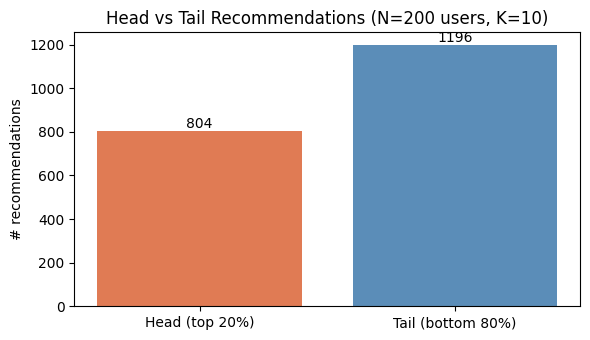

In [33]:
def long_tail_exposure(recommendations: dict, tail_items: set) -> float:
    all_recs = [item for recs in recommendations.values() for item, _ in recs]
    if not all_recs:
        return 0.0
    return sum(1 for item in all_recs if item in tail_items) / len(all_recs)


lte = long_tail_exposure(recommendations, tail_items)

all_recs_flat = [item for recs in recommendations.values() for item, _ in recs]
n_tail_recs   = sum(1 for item in all_recs_flat if item in tail_items)
n_head_recs   = len(all_recs_flat) - n_tail_recs

print(f"Long-tail exposure rate : {lte:.4f}")
print(f"  tail recs : {n_tail_recs} / {len(all_recs_flat)}")
print(f"  head recs : {n_head_recs} / {len(all_recs_flat)}")

# visualise
fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(['Head (top 20%)', 'Tail (bottom 80%)'],
              [n_head_recs, n_tail_recs],
              color=['#e07b54', '#5b8db8'])
ax.bar_label(bars, fmt='%d')
ax.set_ylabel('# recommendations')
ax.set_title(f'Head vs Tail Recommendations (N={len(sampled_users)} users, K={K})')
plt.tight_layout()
plt.show()

## 6. Results Summary

In [34]:
summary = pd.DataFrame([
    {'Metric': 'RMSE (test)',
     'Value': f'{test_rmse:.4f}',
     'Ideal': '→ 0',
     'Interpretation': 'Avg prediction error (rating scale 0.5–5.0)'},
    {'Metric': f'NDCG@{K} (mean over {len(ndcg_scores)} users)',
     'Value': f'{mean_ndcg:.4f}',
     'Ideal': '→ 1',
     'Interpretation': 'Ranking quality; 0 = worst, 1 = perfect order'},
    {'Metric': 'Catalog coverage',
     'Value': f'{cov:.4f} ({len(unique_recommended)}/{len(all_items)} items)',
     'Ideal': '→ 1',
     'Interpretation': 'Fraction of catalog recommended to ≥1 user'},
    {'Metric': 'Long-tail exposure rate',
     'Value': f'{lte:.4f}',
     'Ideal': '→ 0.80',
     'Interpretation': 'Fraction of recs pointing to tail items (80% of catalog)'},
])

summary.set_index('Metric', inplace=True)
summary

,Value,Ideal,Interpretation
Metric,,,
RMSE (test),0.9309,→ 0,Avg prediction error (rating scale 0.5–5.0)
NDCG@10 (mean over 200 users),0.9502,→ 1,"Ranking quality; 0 = worst, 1 = perfect order"
Catalog coverage,0.0007 (12/16825 items),→ 1,Fraction of catalog recommended to ≥1 user
Long-tail exposure rate,0.5980,→ 0.80,Fraction of recs pointing to tail items (80% o...


## 7. Key Observations

**Results summary:**
| Metric | Value |
|--------|-------|
| RMSE | 0.9309 |
| NDCG@10 (closed-world) | 0.9502 |
| Catalog Coverage | 0.0007 (12 / 16,825 items) |
| Long-tail Exposure Rate | 0.5980 |

### 1. Ranking vs prediction accuracy

NDCG@10 of **0.95** means the model is excellent at ranking items the user has already rated —
it correctly surfaces higher-rated items above lower-rated ones within a user's known history.

However, this is **closed-world evaluation**: we only ranked items the user already rated in the
test set. In a real system, the harder problem is surfacing *good unseen items* from the full
catalog of 16,825 items the user hasn't interacted with. The closed-world score measures
preference ordering quality, not discovery quality.

### 2. Popularity bias is quantified

Catalog coverage of **0.07%** (12 items out of 16,825) and long-tail exposure of **0.60**
(vs an ideal of ~0.80 if recommendations were catalog-proportional) confirm that the model
concentrates recommendations on a tiny slice of popular items.

This directly mirrors the Phase 1 finding: the top 20% of items receive ~80% of all ratings,
and the model **amplifies** this rather than correcting it. Nearly every user gets the same
handful of blockbusters at the top of their list regardless of their actual taste profile.

The mechanism is structural: popular items appear in more training pairs, receive more SGD
updates, and develop better-optimised latent factors and bias terms — so they dominate
every ranked list at inference time.

### 3. The NDCG/coverage tension

High NDCG + low coverage is a known failure mode in recommender systems. The model has
learned to rank *within* a user's existing preferences well, but when making open-ended
recommendations from the full catalog it defaults to popular items — exactly the popularity
bias mechanism identified in Phase 1.

These two signals measure different things:
- **NDCG** (closed-world): does the model understand preference ordering?  → Yes (0.95)
- **Coverage** (open-world): does the model explore the catalog?  → No (0.07%)

A system optimised only on RMSE or closed-world NDCG will never surface this problem.

### 4. What's next

These findings motivate the experiment in `docs/ab_test_design.md`: does a
popularity-penalised variant improve long-tail exposure rate and catalog coverage
without unacceptable NDCG loss? The intervention requires no retraining — just subtracting
`α·log(count(i)+1)` from item scores at inference time.